March 2015, J.Slavič and L.Knez

Question 1: For the system of equations:
    $$
    \mathbf{A}=
    \begin{bmatrix}
    1 & -4 & 1\\
    1 & 6 & -1\\
    2 & -1 & 2
    \end{bmatrix}
    \qquad
    \mathbf{b}=
    \begin{bmatrix}
    7\\
    13\\
    5
    \end{bmatrix}
    $$

find the solution using ``SymPy``.

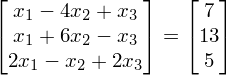

In [1]:
from sympy import *
init_printing()

# Define the symbolic variables
x1, x2, x3 = symbols('x1, x2, x3')

# Define the system
A = Matrix([[1, -4, 1],
            [1, 6, -1],
            [2, -1, 2]])
x = Matrix([[x1],
            [x2],
            [x3]])
b = Matrix([[7],
            [13],
            [5]])

eq = Eq(A*x,b)
eq

In [2]:
solution = solve(eq,[x1, x2, x3])
solution

Question 2: For the matrix $\mathbf{A}$ defined above, determine the Euclidean norm (your own program).

In [3]:
# Convert the data to an np.array

import numpy as np
a = np.array(A).astype(float)   # Make sure to convert to float; by default it is object
a

array([[ 1., -4.,  1.],
       [ 1.,  6., -1.],
       [ 2., -1.,  2.]])

In [4]:
# Fast variant

A_euc = np.sqrt(np.sum(a**2))
A_euc

In [5]:
# Slow variant

total = 0
for row in a:
    for element in row:
        total += element**2

A_euc = total**0.5
A_euc


Question 3: For the matrix $\mathbf{A}$ defined above, determine the infinity norm (your own program).

In [6]:
# Fast variant

A_oo = max(abs(a).sum(axis=1))
A_oo

In [7]:
# Slow variant

total = zeros(1,3)
for i, row in enumerate(a):
    total[i] = sum(abs(row))

A_oo = max(total)
A_oo

Question 4: For the matrix $\mathbf{A}$ defined above, determine the condition number (``numpy`` function).

In [8]:
condition_number = np.linalg.cond(a)
condition_number

Question 5: Define a function ``gauss_elim`` that performs Gaussian elimination for an arbitrary matrix $\mathbf{A}$ and vector $\mathbf{b}$ (separately for the matrix and separately for the vector).

In [9]:
# Define the data
A_data = np.array([[1, -4, 1],
                  [1, 6, -1],
                  [2, -1, 2]], dtype=float)

b_data = np.array([[7],
                  [13],
                  [5]], dtype=float)

In [10]:
# Function
def gauss_elim(A, b):
    n = len(b)

    for k in range(0,n-1):
        for i in range(k+1,n):
            if A[i,k] != 0.0:
                factor =  A[i,k]/A[k,k]
                A[i,k:n] = A[i,k:n] - factor*A[k,k:n]
                b[i] = b[i] - factor*b[k]


    return A, b


In [11]:
# Using the function
[A, b] = gauss_elim(A_data.copy(), b_data.copy())

A

array([[  1. ,  -4. ,   1. ],
       [  0. ,  10. ,  -2. ],
       [  0. ,   0. ,   1.4]])

In [12]:
b

array([[  7. ],
       [  6. ],
       [-13.2]])

Question 6: Define a function ``gauss_elim_x`` that finds the appropriate values of the vector $\textbf{x}$ from the result of the ``gauss_elim`` function.

In [13]:
# Function
def gauss_elim_x(A, b):
    Ab = np.column_stack((A,b))   # Assemble into the system Ab
    n = len(b)
    result = np.zeros(n)             # Prepare a list of zeros for the solution

    for k, row in enumerate(Ab[::-1]):
        result[n-k-1] = (row[-1] - np.dot(row[n-k:-1], result[n-k:]) ) / (row[n-k-1])


    return result

In [14]:
x = gauss_elim_x(A.copy(), b.copy())
x


array([ 11.28571429,  -1.28571429,  -9.42857143])

In [15]:
# Check the solution
residual = np.dot(A_data,x) - b_data.T
residual

array([[ -8.88178420e-16,   0.00000000e+00,  -2.66453526e-15]])